In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.distribution_functions.sampling import sample_df_potential
from phoenix.distribution_functions.disk import f_disc_from_params
from phoenix.potentials.potentials import nfw_potential, miyamoto_nagai_potential


# 1. SETUP POTENTIAL & DF PARAMETERS

In [4]:
# Physical parameters for the potential (Masses in M_sun, Distances in kpc)
M_halo = 1e12
a_halo = 20.0
M_disk = 5e10
a_disk = 3.0
b_disk = 0.3
M_bulge = 0 # Included for network consistency, but we won't sample a bulge DF here
a_bulge = 1.0

def total_potential(x, y, z):
    """Combined gravitational potential (Halo + Disk)."""
    phi_halo = nfw_potential(x, y, z, M_halo, a_halo)
    phi_disk = miyamoto_nagai_potential(x, y, z, M_disk, a_disk, b_disk)
    return phi_halo + phi_disk

In [5]:
# Parameters for the Quasi-Isothermal Disk DF
df_params = {
    "R0": 8.0,
    "Rd": 3.0,
    "Sigma0": 1000.0,
    "RsigR": 6.0,
    "RsigZ": 6.0,
    "sigmaR0_R0": 35.0,
    "sigmaz0_R0": 20.0,
    "L0": 10.0,
    "Rinit_for_Rc": 8.0
}

In [6]:
# Parameters required by the Phoenix Neural Network
# (Must match the exact structure used during training: Masses scaled by 1e11)
nn_potential_params = np.array([
    M_halo / 1e11, a_halo,
    M_disk / 1e11, a_disk, b_disk,
    M_bulge / 1e11, a_bulge
])

# 2. DIFFERENTIABLE SAMPLING

In [7]:
print("Starting differentiable action sampling...")
N_samples = 100_000
key = jax.random.PRNGKey(42)

# Find a rough estimate of the max DF value to use as 'envelope_max'
# (We evaluate the DF at a typical disk orbit to set the scale)
test_val = f_disc_from_params(10.0, 5.0, 2000.0, total_potential, (), df_params)
envelope_max = float(test_val) * 2.0  # Buffer it slightly


Starting differentiable action sampling...


In [8]:
# Sample the DF using the soft acceptance logic
# Bounds: Jr_max=100, Jz_max=50, Lz_max=3000 (tuned for a typical disk)
candidates, soft_weights = sample_df_potential(
    df=f_disc_from_params,
    key=key,
    params=df_params,
    Phi_xyz=total_potential,
    theta=(),
    n_candidates=N_samples,
    envelope_max=envelope_max,
    J_bounds=(100.0, 50.0, 3000.0),
    tau=0.05
)

# Generate uniform random angles [0, 2*pi] to complete the action-angle coordinates
key, subkey = jax.random.split(key)
angles = jax.random.uniform(subkey, shape=(N_samples, 3), minval=0.0, maxval=2*jnp.pi)


# 3. MAPPING ACTIONS TO PHASE SPACE

In [9]:
print("Mapping actions to phase space using Phoenix Surrogate...")
mapper = PhoenixMapper()

# We tile the potential array to match the batch size for the network
potentials_batch = np.tile(nn_potential_params, (N_samples, 1))

# Execute the Neural Network Mapping (converting JAX arrays to NumPy for easy plotting)
phase_space = mapper.map_to_phase_space(np.array(candidates), np.array(angles), potentials_batch)
x, y, z = phase_space[:, 0], phase_space[:, 1], phase_space[:, 2]
vx, vy, vz = phase_space[:, 3], phase_space[:, 4], phase_space[:, 5]
weights = np.array(soft_weights)


Mapping actions to phase space using Phoenix Surrogate...
Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


# 4. PLOTTING SPATIAL PLANES

Generating Spatial Density plots...


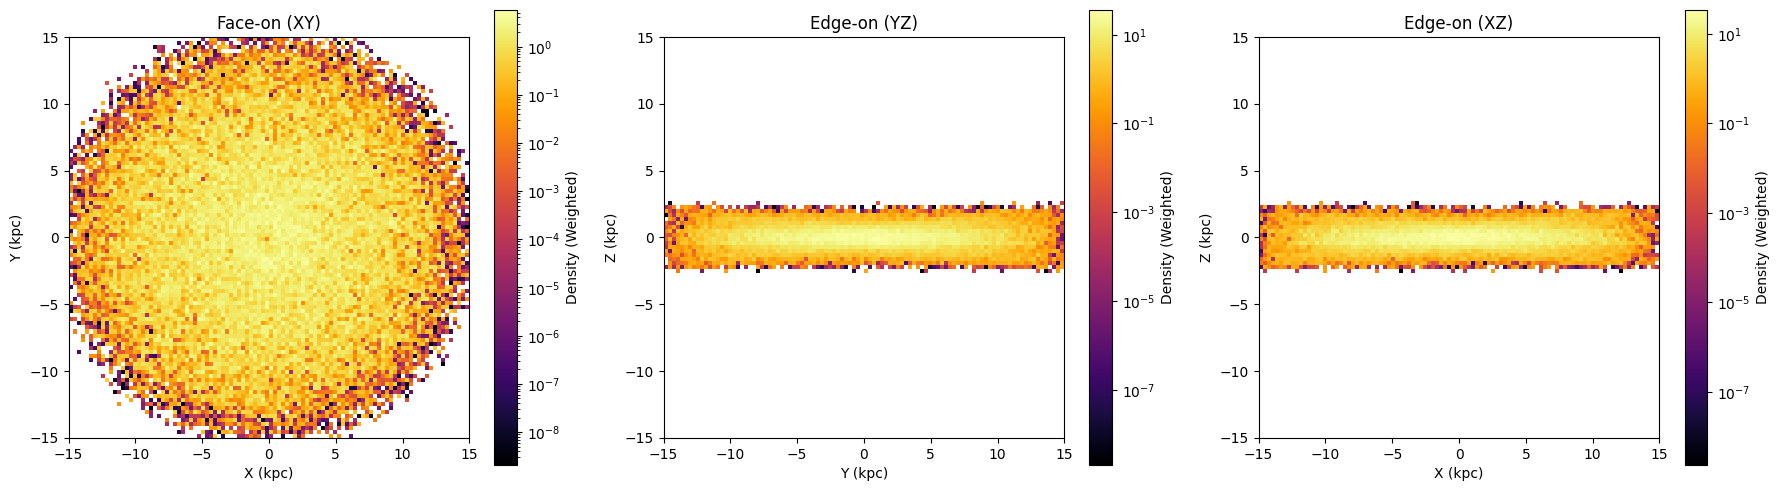

In [10]:
print("Generating Spatial Density plots...")
fig_space, axes_space = plt.subplots(1, 3, figsize=(18, 5))

# We use hist2d with 'weights' to apply the soft acceptance mask!
planes = [(x, y, 'X (kpc)', 'Y (kpc)', 'Face-on (XY)'),
          (y, z, 'Y (kpc)', 'Z (kpc)', 'Edge-on (YZ)'),
          (x, z, 'X (kpc)', 'Z (kpc)', 'Edge-on (XZ)')]

for i, (coord1, coord2, xlabel, ylabel, title) in enumerate(planes):
    ax = axes_space[i]
    h = ax.hist2d(coord1, coord2, bins=100, range=[[-15, 15], [-15, 15]], 
                  weights=weights, cmap='inferno', norm=LogNorm())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect('equal')
    fig_space.colorbar(h[3], ax=ax, label='Density (Weighted)')

plt.tight_layout()
plt.show()

# 5. GAUSS-HERMITE LINE-OF-SIGHT KINEMATICS

In [14]:
print("Generating Gauss-Hermite Kinematic maps (Edge-on XZ projection)...")

def gauss_hermite(v, v_rot, v_disp, h3, h4):
    """Gauss-Hermite expansion for line-of-sight velocity distribution."""
    y = np.asarray((np.asarray(v) - v_rot) / (v_disp))
    return (np.exp(-0.5 * y**2)/(v_disp*np.sqrt(2*np.pi)) )* (
        1
        + h3 * ((2 * np.sqrt(2) * y**3 - 3 * np.sqrt(2) * y) / np.sqrt(6))
        + h4 * ((4 * y**4 - 12 * y**2 + 3) / np.sqrt(24))
    )

def fit_losvd_weighted(v_bin, w_bin):
    """Fit Gauss-Hermite expansion to a soft-weighted velocity distribution."""
    if len(v_bin) < 10 or np.sum(w_bin) < 1.0:
        return np.nan, np.nan, np.nan, np.nan
        
    hist, bins = np.histogram(v_bin, bins=30, density=True, weights=w_bin)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Initial guess derived from the weighted standard moments
    V_guess = np.average(v_bin, weights=w_bin)
    variance = np.average((v_bin - V_guess)**2, weights=w_bin)
    sigma_guess = np.sqrt(variance)
    
    if sigma_guess == 0:
        return V_guess, 0.0, 0.0, 0.0
        
    p0 = [V_guess, sigma_guess, 0.1, 0.1]
    
    try:
        popt, _ = curve_fit(gauss_hermite, bin_centers, hist, p0=p0, maxfev=10000)
    except (RuntimeError, ValueError, TypeError):
        return np.nan, np.nan, np.nan, np.nan
        
    return popt


Generating Gauss-Hermite Kinematic maps (Edge-on XZ projection)...


<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_846639/4051823822.py:42: SyntaxWarning: invalid escape sequence '\s'
  (sigma_map, 'Dispersion ($\sigma$)', 'viridis', 0, 100),


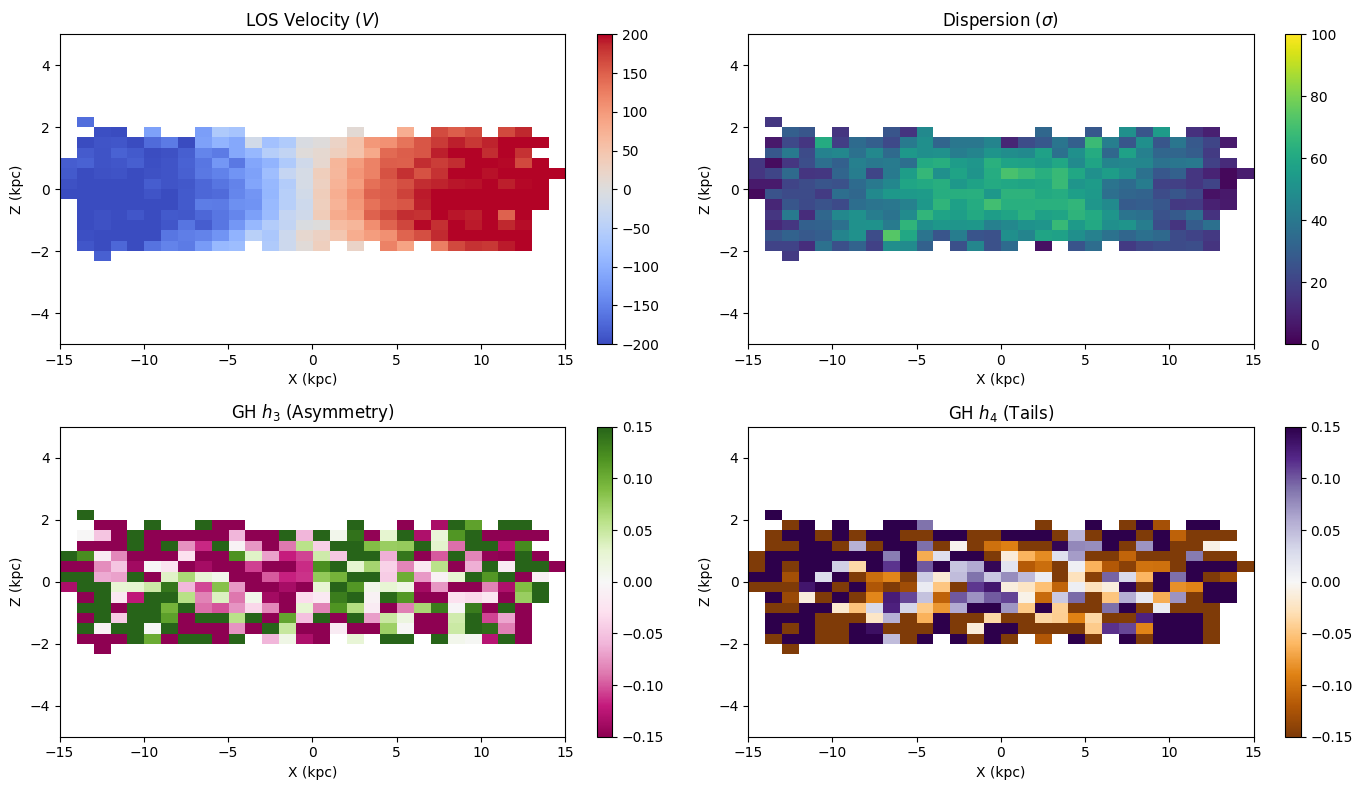

In [15]:
# We observe edge-on along the Y-axis. Therefore:
# - Spatial coordinates on sky: X and Z
# - Line-of-sight (LOS) velocity: Vy

grid_size = 30
x_bins = np.linspace(-15, 15, grid_size + 1)
z_bins = np.linspace(-5, 5, grid_size + 1)

V_map = np.zeros((grid_size, grid_size))
sigma_map = np.zeros((grid_size, grid_size))
h3_map = np.zeros((grid_size, grid_size))
h4_map = np.zeros((grid_size, grid_size))

# Bin the particles to calculate weighted kinematic moments
for i in range(grid_size):
    for j in range(grid_size):
        # Find particles in this spatial (x, z) pixel
        mask = (x >= x_bins[i]) & (x < x_bins[i+1]) & (z >= z_bins[j]) & (z < z_bins[j+1])
        w_bin = weights[mask]
        
        if np.sum(w_bin) < 1.0 or len(vy[mask]) < 10: # Skip empty or extremely low-weight bins
            V_map[j, i] = np.nan; sigma_map[j, i] = np.nan
            h3_map[j, i] = np.nan; h4_map[j, i] = np.nan
            continue
            
        v_bin = vy[mask]
        
        # Fit using the Scipy curve_fit logic
        v_rot, v_disp, h3, h4 = fit_losvd_weighted(v_bin, w_bin)
        
        V_map[j, i] = v_rot
        sigma_map[j, i] = v_disp
        h3_map[j, i] = h3
        h4_map[j, i] = h4

# Plotting the Kinematic Maps
fig_kin, axes_kin = plt.subplots(2, 2, figsize=(14, 8))
axes_kin = axes_kin.flatten()

maps = [
    (V_map, 'LOS Velocity ($V$)', 'coolwarm', -200, 200),
    (sigma_map, 'Dispersion ($\sigma$)', 'viridis', 0, 100),
    (h3_map, 'GH $h_3$ (Asymmetry)', 'PiYG', -0.15, 0.15),
    (h4_map, 'GH $h_4$ (Tails)', 'PuOr', -0.15, 0.15)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(maps):
    ax = axes_kin[i]
    im = ax.imshow(data, origin='lower', extent=[x_bins[0], x_bins[-1], z_bins[0], z_bins[-1]], 
                   cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('X (kpc)')
    ax.set_ylabel('Z (kpc)')
    fig_kin.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_846639/1544772072.py:42: SyntaxWarning: invalid escape sequence '\s'
  (sigma_map, 'Dispersion ($\sigma$)', 'viridis', 0, 100),


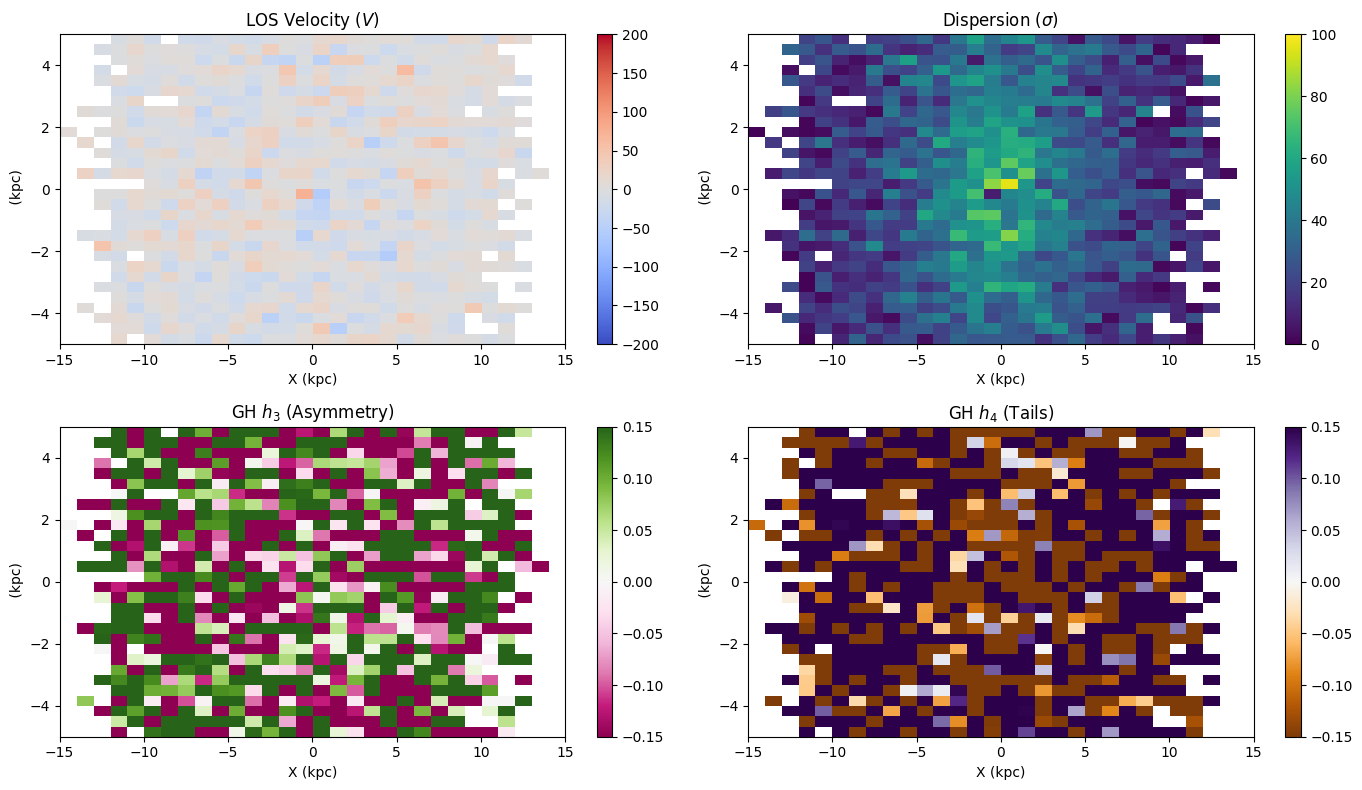

In [16]:
# We observe face-on along the Z-axis. Therefore:
# - Spatial coordinates on sky: X and Y
# - Line-of-sight (LOS) velocity: Vz

grid_size = 30
x_bins = np.linspace(-15, 15, grid_size + 1)
y_bins = np.linspace(-5, 5, grid_size + 1)

V_map = np.zeros((grid_size, grid_size))
sigma_map = np.zeros((grid_size, grid_size))
h3_map = np.zeros((grid_size, grid_size))
h4_map = np.zeros((grid_size, grid_size))

# Bin the particles to calculate weighted kinematic moments
for i in range(grid_size):
    for j in range(grid_size):
        # Find particles in this spatial (x, y) pixel
        mask = (x >= x_bins[i]) & (x < x_bins[i+1]) & (y >= y_bins[j]) & (y < y_bins[j+1])
        w_bin = weights[mask]
        
        if np.sum(w_bin) < 1.0 or len(vz[mask]) < 10: # Skip empty or extremely low-weight bins
            V_map[j, i] = np.nan; sigma_map[j, i] = np.nan
            h3_map[j, i] = np.nan; h4_map[j, i] = np.nan
            continue
            
        v_bin = vz[mask]
        
        # Fit using the Scipy curve_fit logic
        v_rot, v_disp, h3, h4 = fit_losvd_weighted(v_bin, w_bin)
        
        V_map[j, i] = v_rot
        sigma_map[j, i] = v_disp
        h3_map[j, i] = h3
        h4_map[j, i] = h4

# Plotting the Kinematic Maps
fig_kin, axes_kin = plt.subplots(2, 2, figsize=(14, 8))
axes_kin = axes_kin.flatten()

maps = [
    (V_map, 'LOS Velocity ($V$)', 'coolwarm', -200, 200),
    (sigma_map, 'Dispersion ($\sigma$)', 'viridis', 0, 100),
    (h3_map, 'GH $h_3$ (Asymmetry)', 'PiYG', -0.15, 0.15),
    (h4_map, 'GH $h_4$ (Tails)', 'PuOr', -0.15, 0.15)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(maps):
    ax = axes_kin[i]
    im = ax.imshow(data, origin='lower', extent=[x_bins[0], x_bins[-1], z_bins[0], z_bins[-1]], 
                   cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('X (kpc)')
    ax.set_ylabel(' (kpc)')
    fig_kin.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()